# Research Methods <br>UHH - Knowledge Technology Research Group - WiSe 2025/2026
## Assignment #3 - Multivariate EDA & Testing Procedures

***
### Group: A
### Names of members: Niloufar Baba Ahmadi, Narges Baba Ahmadi, Alexandra Helen Hooser

***

### Instructions:

Please answer the questions below. Copy this notebook and enter your answers underneath each task description, inserting cells as needed. You may use a combination of [python 3](https://www.python.org), [markdown](http://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html), and [LaTex](https://towardsdatascience.com/write-markdown-latex-in-the-jupyter-notebook-10985edb91fd) to formulate your responses. In order to successfully complete the assignment, you will need the lecture material provided in the [RM moodle course](https://lernen.min.uni-hamburg.de/course/view.php?id=5728), especially L04 & L05.

**Make sure to use only a copy of this notebook for your answers instead of a new/blank notebook.**

### Grading Criteria:

In order to successfully pass this assignment, you will need **at least a total of 70 points out of 100 points**, and every task has to be tackled.

### Submission:

Please upload the following two files **until Tuesday, November 18, 2025, 20:00 CET (Germany)** together in a .zip archive in moodle:
1. a (single) copy of this jupyter notebook containing your answers for all tasks (file extension: .ipynb)
2. an [exported PDF document](https://jupyterlab.readthedocs.io/en/stable/user/export.html) of the jupyter notebook (file extension: .pdf)

### Presentation:

Make sure that each (!) group member takes part in solving this assignment and is prepared to answer questions and/or present solutions from your submitted notebook during our assignment revision meeting scheduled for **Wednesday, November 26, 2025, 10:00 - 13:00 CET (Germany)**.

### File Naming:

Add the group letter to the file name prior to submission. For example, if your group letter is "A" (see group selection in moodle), you would use the following filename:
1. RM_A03_Group_A.ipynb
2. RM_A03_Group_A.pdf

***
***

As a reminder of how to present and be critical with your results in this assignment:

**Imagine you are a member of a climate research committee. Fellow scientists, journalists, and politicians are interested in your results and your critical scientific evaluation.**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
from pandas.api.types import is_numeric_dtype, is_string_dtype
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr

#### Task 1 **[30 points] Correlation Analysis**

For this task, your goal is to perform a correlation analysis on the statistical measurement "[annual CO<sub>2</sub> emissions](https://ourworldindata.org/grapher/annual-co2-emissions-per-country?tab=chart&facet=none&country=~OWID_WRL)" and statistical measurements "mean temperature" and "precipitation" from the CRU climate dataset, with each year representing one data sample. You can download the data associated with the CO<sub>2</sub> emission plot using the link provided above (when accessing each URL, go to menu item _download_ right below the visualization plot).

For this task, use data from years 1901-2023 from the country/entity "WORLD" of each the CRU dataset and the CO<sub>2</sub> emission dataset.

1. Download and import the CO<sub>2</sub> emission dataset and merge the values with the data from the CRU dataset (grouped by year). The result should be a dataframe that contains the annual CO<sub>2</sub> emissions as well as mean temperature and precipitation for each respective year.
2. Create two scatter plots: One showing annual CO<sub>2</sub> emissions vs. annual mean temperature and the second showing annual CO<sub>2</sub> emissions vs. precipitation.
3. Fit linear regression models to the data used in the scatter plots (e.g., using the [scikit-learn library](https://scikit-learn.org/stable/index.html)) and add the two resulting regression lines to both scatter plots from the previous part of this task.
4. Calculate the Pearson's correlation coefficient for the measurements used in both scatter plots respectively and explain your result briefly.
5. Explain in your own words the following factors that have to be considered when interpreting a correlation coefficient: (A) non-linear relationship, (B) outliers, and (C) correlation vs. causality.

### Task 1.1

In [ ]:
# df_CRU = pd.read_csv("/content/drive/MyDrive/RM seminar/A03/data/CRU_data.csv")
# df_CO2 = pd.read_csv("/content/drive/MyDrive/RM seminar/A03/data/annual-co2-emissions-world.csv")

df_CRU = pd.read_csv("CRU_data.csv")
df_CO2 = pd.read_csv("annual-co2-emissions-world.csv")

# df_CRU = pd.read_csv('CRU_data.csv') #uncomment if you are running outside of drive :)
# df_CO2 = pd.read_csv('annual-co2-emissions-world.csv')

In [ ]:
# Preparing the CRU data
months = ['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC']

df_CRU = df_CRU.copy()
df_CRU.replace(-999, np.nan, inplace=True)


var_prefixes = ["TMP_MEAN_", "PRECIP_"]

keep_cols = ['COUNTRY', 'YEAR'] + [
    col for col in df_CRU.columns
    for prefix in var_prefixes
    if col.startswith(prefix) and col.split('_')[-1] in months
]

df_CRU_avg = df_CRU[keep_cols].copy()


tmp_months = [c for c in df_CRU_avg.columns if c.startswith("TMP_MEAN_")]
precip_months = [c for c in df_CRU_avg.columns if c.startswith("PRECIP_")]

df_CRU_avg["TMP_AVG"] = df_CRU_avg[tmp_months].mean(axis=1)
df_CRU_avg["PRECIP_AVG"] = df_CRU_avg[precip_months].mean(axis=1)

df_CRU_avg = df_CRU_avg[["COUNTRY", "YEAR", "TMP_AVG", "PRECIP_AVG"]]


df_CRU_avg_World = (df_CRU_avg.query("COUNTRY == 'WORLD' and 1901 <= YEAR <= 2023").rename(columns={"YEAR": "Year"}))

# ---------------------------------------------------------------
# Preparing the CO2 data

df_CO2_avg = (df_CO2.copy().rename(columns={"Entity": "COUNTRY"}).drop(columns=["Code"]))

df_CO2_avg = df_CO2_avg.query("1901 <= Year <= 2023")
df_CO2_avg["COUNTRY"] = df_CO2_avg["COUNTRY"].replace("World", "WORLD")

# df_CO2_avg.describe()

In [ ]:
df_all = pd.merge(df_CO2_avg, df_CRU_avg_World, on=['COUNTRY', 'Year'], how='inner')

df_all.head()

,COUNTRY,Year,Annual CO₂ emissions,TMP_AVG,PRECIP_AVG
0,WORLD,1901,2025628200,13.066667,67.983333
1,WORLD,1902,2076956000,12.833333,67.033333
2,WORLD,1903,2264592000,12.866667,68.858333
3,WORLD,1904,2290254800,12.808333,68.283333
4,WORLD,1905,2440570600,12.875000,68.341667


A dataframe has been created here by combining the data points from the CRU dataset with the CO₂ emission data for the world from 1901 to 2023.

### Task 1.2

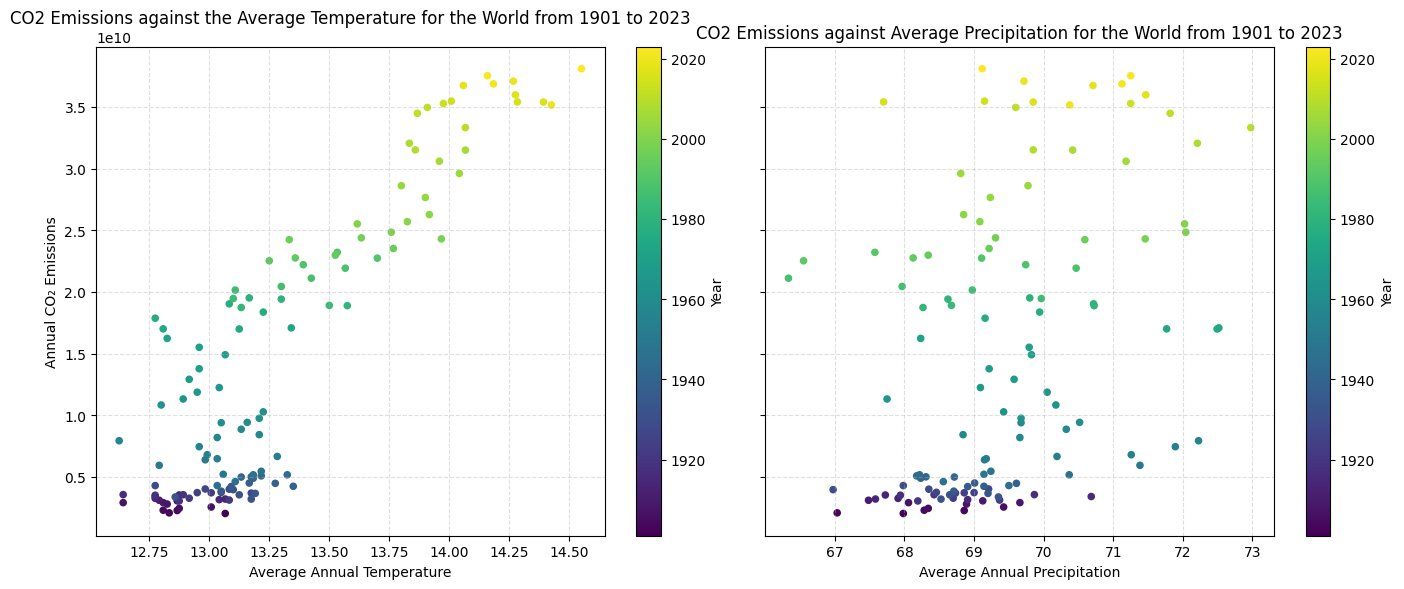

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

df_all.plot.scatter(
    x="TMP_AVG",
    y="Annual CO₂ emissions",
    c="Year",
    colormap="viridis",
    ax=axes[0],
    title="CO2 Emissions against the Average Temperature for the World from 1901 to 2023",
    xlabel="Average Annual Temperature",
    ylabel="Annual CO₂ Emissions"
)
axes[0].grid(True, linestyle="--", alpha=0.4)


df_all.plot.scatter(
    x="PRECIP_AVG",
    y="Annual CO₂ emissions",
    c="Year",
    colormap="viridis",
    ax=axes[1],
    title="CO2 Emissions against Average Precipitation for the World from 1901 to 2023",
    xlabel="Average Annual Precipitation",
    ylabel=""
)

axes[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

To make the graph more legible and comparitative across the years there is a gradient that was placed on the data points to roughly depict when from 1901-2023 the emission/temperature/precipitation was taken.

In the first graph, the annual emissions are being graphed in comparison to the mean temperature per year. The emissions are significantly lower than that of later years. There is a dense clustering of data points from the early 20th century (~1901 - ~1950), where the mean temperature remains roughly in the same range of ~12.75 - ~13.25, however the emissions slowly rises throughout the years. Between 1950-1975 there is a slight increase in temperature and emissions, with emissions never dropping below 1.5e10 anymore. One of the highest points of emission and temperature was recorded in the late 2000. Based upon initial observation, it would seem that the graph has a positive trend (this will be either confimed or denied later with pearson's coeff).

The second graph maps the annual CO2 emissions vs the average precipitation recorded from 1901-2023. Similarily as the first graph, the data points in this graph from ~1901-1950 are densly compact with low emissions ~0.25-0.75e10 and precipitation ranging around 67-70mm. As the years progress, the emissions continue to increase, with the highest emission recording being in the late 2000. The precipitation, on the other hand, seems to vary significantly more with points eing larger apart and more spread throughout the graph.

### Task 1.3

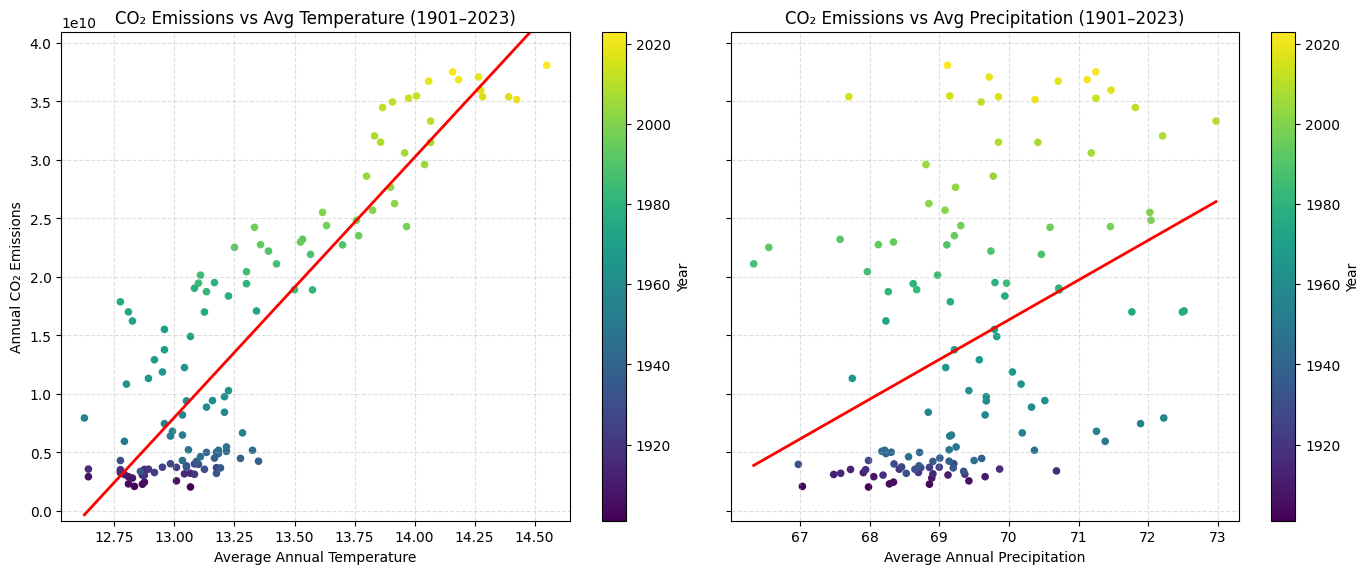

In [ ]:
X_temp = df_all['TMP_AVG'].values.reshape(-1, 1)
X_precip = df_all['PRECIP_AVG'].values.reshape(-1, 1)
y_co2 = df_all['Annual CO₂ emissions'].values

reg_temp = LinearRegression().fit(X_temp, y_co2)
reg_precip = LinearRegression().fit(X_precip, y_co2)

y_min, y_max = y_co2.min(), y_co2.max()
padding = 0.08 * (y_max - y_min)
y_min -= padding
y_max += padding

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

df_all.plot.scatter(
    x="TMP_AVG",
    y="Annual CO₂ emissions",
    c="Year",
    colormap="viridis",
    ax=axes[0],
    title="CO₂ Emissions vs Avg Temperature (1901–2023)",
    xlabel="Average Annual Temperature",
    ylabel="Annual CO₂ Emissions"
)

temp_range = np.linspace(df_all['TMP_AVG'].min(), df_all['TMP_AVG'].max(), 200).reshape(-1, 1)
axes[0].plot(temp_range, reg_temp.predict(temp_range), color="red", linewidth=2)
axes[0].set_ylim(y_min, y_max)
axes[0].grid(True, linestyle="--", alpha=0.4)

df_all.plot.scatter(
    x="PRECIP_AVG",
    y="Annual CO₂ emissions",
    c="Year",
    colormap="viridis",
    ax=axes[1],
    title="CO₂ Emissions vs Avg Precipitation (1901–2023)",
    xlabel="Average Annual Precipitation",
    ylabel=""
)

precip_range = np.linspace(df_all['PRECIP_AVG'].min(), df_all['PRECIP_AVG'].max(), 200).reshape(-1, 1)
axes[1].plot(precip_range, reg_precip.predict(precip_range), color="red", linewidth=2)
axes[1].set_ylim(y_min, y_max)
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

As these graphs are the same as those in task 1.2, this description will focus solely on the regression lines. These lines help to visualise the relationship between the data points by drawing a 'line of best fit'.

In the graph showing annual emissions vs temperature, the points generally seem to follow the positive regression line. It is interesting to note that there is very little overlap between the data from later and previous years. One could argue that the model is fairly 'linear' because of this. While this suggests a strong correlation between CO₂ emissions and temperature, one cannot assume causation.

Moving on to the graph showing annual CO₂ emissions in comparison to precipitation, it would seem that the relationship between the variables is weaker. This is evident in the steepness of the regression line, as well as the fact that the data points are significantly more dispersed throughout the graph. The precipitation averages show high variability that does not increase as steadily as the temperature did over the years.

### Task 1.4

In [ ]:
r_temp, p_temp = pearsonr(df_all['Annual CO₂ emissions'], df_all['TMP_AVG'])
print(f"Pearson r (CO2 Emissions vs Temperature): {r_temp:.3f}, p-value: {p_temp:.3e}")

r_precip, p_precip = pearsonr(df_all['Annual CO₂ emissions'], df_all['PRECIP_AVG'])
print(f"Pearson r (CO2 Emissions vs Precipitation): {r_precip:.3f}, p-value: {p_precip:.3e}")

Pearson r (CO2 Emissions vs Temperature): 0.878, p-value: 1.461e-40
Pearson r (CO2 Emissions vs Precipitation): 0.390, p-value: 8.317e-06


The Pearson's correlation coefficient for CO2 Emissions vs Temperature is 0.878 with a p-value of 1.461e-40. These are very strong positive results, suggesting that as the emissions increase, so does the average temperature. This statement is supported by such a low p-value as well, implying a statistical significance in the result.

The Pearson's correlation coefficient for CO2 Emissions vs Precipitation is 0.390 with a p-value of 8.317e-06. This result shows a weak/moderate association between the variables. The p-value is still small, depicting the association that can be seen, however, in comparison to temperature and CO2 emissions, CO2 emissions and precipitation are weak predictors of each other.

### Task 1.5

Considerations needed when interpreting of the correlation coefficient:

(A) **non-linear relationship** - Pearson's correlation coefficient is to be used when measuring the relationship of two variables that have a linear relationship. If a model were to be non-linear (ex. curve, U-shape, etc.), even if there is a correlation between two variables there would be a very small Person's R value as it is trying to fit a linear line to a non-linear shape. Generally visualizing data can help discover the suspected shape of the data, or doing non-linear correlation tests to fully inspect all possibilities.

(B) **outliers** - these are extreme data points that do not follow the general pattern of the model/rest of the data. These can affect Pearson's R by making it stronger or weaker depending. These can generally be seen with a scatterplot, however looks can often be deceiving, so using other statistical methods that are more robust to outliers could be helpful to further investigate data.

(C) **correlation vs. causality** - as mentioned in a previous question correlation does not equal causation. This is a dangerous assumption to make. Pearson's correlation coefficient measures the relationship (correlation) between two variables and if this is close to 1 (strong correlation), it means that these variables influence each other one way or another. However, the nature of this relationship isn't fully known. It would be that there is a third unknown variable that is actually influencing the other two. Therefore, even with a high correlation, causation can never be assumed unless there has been thorough testing in a manipulation study.

#### Task 2 **[30 points] Hypothesis Testing**

Imagine you want to determine whether global monthly mean temperatures are increasing using the number of warmer and colder months (with respect to the same month 50 years ago, as calculated in Assignment 2) as sample data.





1. State hypotheses $H_0$ and $H_1$ and briefly evaluate whether they're testable and falsifiable.


We defined “warmer month” as: the global mean temperature in a given month is higher than in the same calendar month 50 years earlier.


- Null hypothesis $H_0$: there are no systematic increases in global monthly mean temperatures compared to 50 years ago. Formally, the probability that a randomly chosen month is warmer than the same month 50 years ago is

<center>$P(warmer)=0.5$.</center>

(positive and negative differences are equally likely.)

- Alternative hypothesis $H_1$: Global monthly mean temperatures are increasing
<center>$P(warmer)>0.5$.</center>

(“are temperatures increasing?” → one-sided)

**Testable**: Yes because we have binary data (True/False), which indicates if a month was hotter compared to a month 50 years ago.

**Falsifiable**: Yes. If the data show roughly 50% warmer and 50% colder months (within random variation), we fail to reject $H_0$. If we observe significantly more than 50% warmer months, we reject $H_0$ in favor of $H_1$. So the hypotheses can be contradicted by observed data.


2. Define both type 1 ($\alpha$) and type 2 ($\beta$) error for the given hypotheses. What is the meaning and what would be the consequence of these errors given your hypotheses?

- Type 1 error ($\alpha$): rejecting $H_0$ even though $H_0$ is actually true and concluding that global monthly mean temperatures are increasing ($P(warmer)>0.5$) even though in reality there is no systematic warming and ($P(warmer)=0.5$)
- - consequence: We would overstate climate warming based on this temperature comparison which can lead to unjustified alarm or policies based on an apparent warming signal that is actually just random variation in the data (from the perspective of this test).

- Type 2 error ($\beta$): failing to reject $H_0$ even though $H_1$ is true and concluding there is no evidence for an increase (($P(warmer)=0.5$) even though in truth $P(warmer)>0.5$ (global temperatures really are increasing).
- - consequence: We miss a real warming trend present in the data. We underestimate or ignore actual climate change, which can delay appropriate responses or adaptation.

3. Is the hypothesis test you would perform to answer the given question one-sided or two-sided? Briefly explain your choice.

One-sided test with alternative $H_1$: $p>0.5$. A two-sided test would be used if the question were “are monthly mean temperatures different from 50 years ago (warmer or colder)?” which isn't what's asked here.

4. Define the term "statistical power" and its characteristics with respect to the given research question.

The statistical power of the test is the probability of rejecting $H_0$ when $H_1$ is true. It is the probability that we reject the null hypothesis that there are no significant changes in global monthly mean temperatures compared to 50 years ago and accept the alternative hypothesis that global monthly mean temperatures have increased compared to 50 years ago, given that $H_1$ is actually true. The power of the test depends on:

- Sample size (N): Number of months analyzed. The more months we include (i.e., the more data points we have), the higher the power in general, because the test can more easily detect a true increase. In practice, extremely large N can make even very small, practically negligible changes appear statistically significant, but mathematically, power does not decrease with larger N.

- Significance level (α): is the probability of incorrectly rejecting the null hypothesis when it is true (Type I error). If we set α very high, we increase the risk of mistakenly detecting a temperature change when it does not exist.
A higher α increases power, but also increases the chance of a false alarm.

- Variance of the data / magnitude of noise: This is the variability in the temperature differences. Higher variance (more noise in monthly temperatures) generally decreases power, because it makes it harder to distinguish a real warming signal from random fluctuations.

- Effect size (δ = $μ_1$ − $μ_0$): degree of separation between the distributions could represent the mean global monthly temperature 50 years ago and the mean global monthly temperature now. The effect size δ is the difference between current and past global monthly mean temperatures. If temperatures today are substantially higher than 50 years ago, $|δ|$ is large, which increases power and makes it easier for the test to detect the change.

5. Apart from the CO<sub>2</sub> emissions as explored in Task 1, which other extraneous factors may also influence the difference of monthly mean temperatures?

Besides CO₂ emissions, other factors that can influence the difference in monthly mean temperatures could be many factors such as:

- Other greenhouse gases (e.g. methane, nitrous oxide).
- Volcanic eruptions.
- Meteorological phenomenon such as El Niño.
- Urbanization and the urban heat island effect
- Deforestation

#### Task 3 **[40 points] Time Series Analysis**

Your goal for this task is to do a time series analysis on two unknown time series. You can download the two series through an API call (see below). <br>
<b>Please note the following things:</b>

- The data server will always return slightly <b>different data</b> on each API call!
- You can use the code below to retrieve the data once(!), save the data into a file, share it with your team members, and then use the file for further analysis. This way everyone in the group is always working on the same data.
- Submit the data file, <b>including the retrieval date</b> (as shown in the example code), so that we can see what data you have based your analysis on.
- The example code does not have to be submitted (i.e., you can delete it once you have the data saved).

On the retrieved data, please perform the following analysis:
1. Plot the two time series so that they can be visually compared. Analyze them visually and state some first hypotheses based on your visual analysis.
2. Perform smoothing on each time series and plot the smoothed series together with the original. Make sure the viewer can clearly recognize which line is the smoothed one. For the smoothing procedure, choose a method and window size $n$ that makes most sense to you. Explain and evaluate your choice briefly.
3. Using appropriate statistics, analyze both time series to look for the following: (A) trend, (B) cyclic variation, and (C) cross correlations. For each feature, explain what the analysis has shown.
4. Revisit your first hypotheses from Task 3.1 and interpret all findings from Task 3.2 and Task 3.3 in the light of your first ideas. How has your first impression changed? What have you been able to show through your analysis? What do the results mean in terms of predictive power?      

### Task 3.1:

In [ ]:
import pandas as pd

# Skip the first metadata line
df = pd.read_csv('A03_data.csv', skiprows=1)

# Drop the first unnamed/NaN column if it exists
df = df.drop(columns=[df.columns[0]])

# Reset column names just to be safe
df.columns = ['T1', 'T2']

# Add a proper time index (0, 1, 2, ...)
df.index.name = 'Time'

print(df.head())


              T1         T2
Time                       
0     206.835592  88.102657
1     206.752239  88.369924
2     208.523678  85.630753
3     203.469827  86.798477
4     205.231336  87.165027


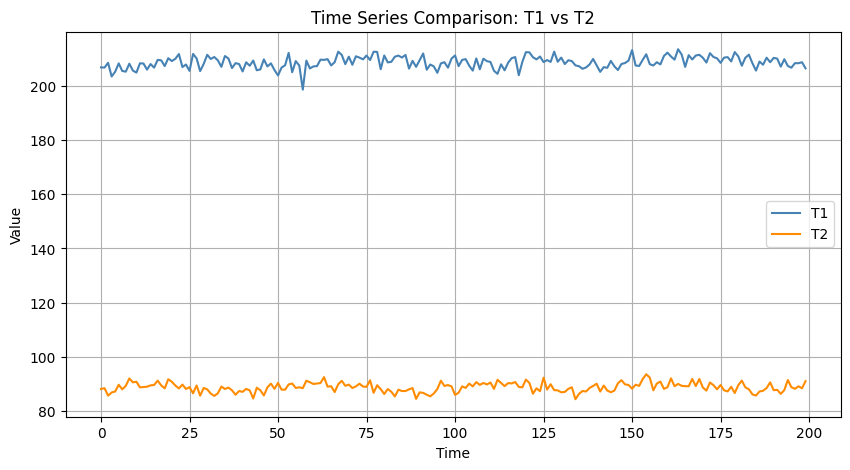

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(df.index, df['T1'], label='T1', color='steelblue')
plt.plot(df.index, df['T2'], label='T2', color='darkorange')
plt.title('Time Series Comparison: T1 vs T2')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

The plot shows two time series, T1 (blue) and T2 (orange), recorded over approximately 200 time steps. Both series fluctuate around relatively stable mean values without any obvious upward or downward long-term trend. This indicates that both might be approximately stationary, at least visually.

T1 exhibits small but frequent oscillations, with slightly sharper peaks and dips compared to T2, suggesting more short-term variability or noise in the signal. In contrast, T2 fluctuates more smoothly with smaller amplitude, implying it could represent a more stable process or one with natural damping.

Despite similar general stability, the two series operate on very different scales, with T1 roughly twice the magnitude of T2. Their fluctuations do not appear to occur in sync, meaning when T1 increases, T2 does not necessarily follow, suggesting little to no immediate correlation between them.

#### **First Hypotheses**

1. **Stationary around a mean:**
   Both **T1** and **T2** fluctuate around stable levels with no obvious trend or seasonality, indicating visually consistent stationary behavior.

2. **Different volatility:**
   **T1** shows noticeably higher short-term variability, with more frequent small spikes and dips compared to the smoother **T2**.

3. **No clear cycles:**
   If any cyclic pattern exists, it appears low in amplitude and short-lived; no strong periodicity is evident in either series.

4. **Different processes and scales:**
   Given the distinct scales and fluctuation patterns, **T1** and **T2** likely capture different underlying phenomena. They should be normalized before any quantitative comparison.


### Task 3.2:
Perform smoothing on each time series and plot the smoothed series together with the original. Make sure the viewer can clearly recognize which line is the smoothed one. For the smoothing procedure, choose a method and window size  𝑛  that makes most sense to you. Explain and evaluate your choice briefly.

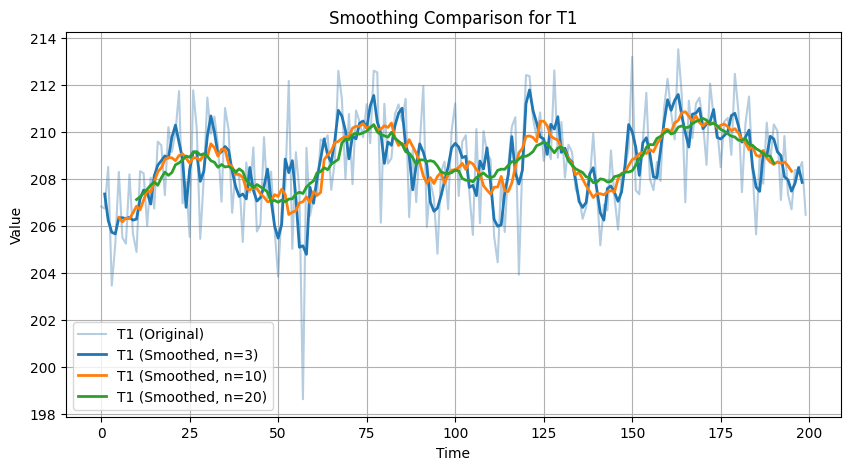

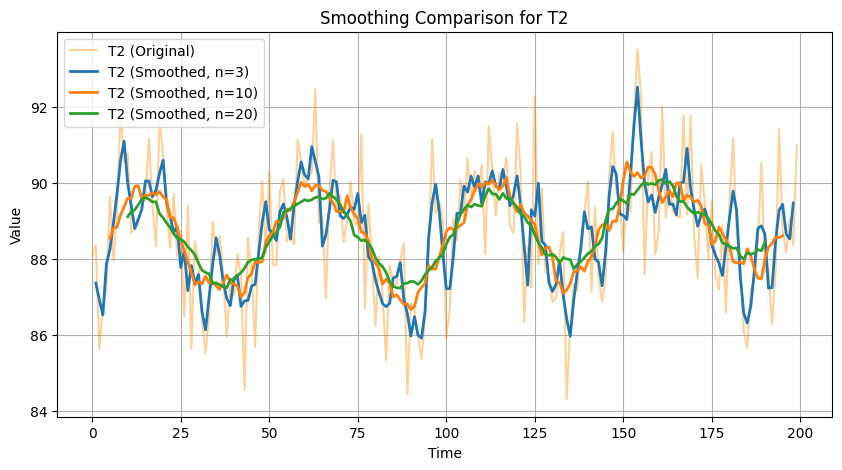

In [ ]:
# Define window sizes for smoothing
windows = [3, 10, 20]

# Apply moving averages for each window size
for n in windows:
    df[f'T1_smooth_{n}'] = df['T1'].rolling(window=n, center=True).mean()
    df[f'T2_smooth_{n}'] = df['T2'].rolling(window=n, center=True).mean()

# --- Plot T1 ---
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['T1'], label='T1 (Original)', color='steelblue', alpha=0.4)
for n in windows:
    plt.plot(df.index, df[f'T1_smooth_{n}'], label=f'T1 (Smoothed, n={n})', linewidth=2)
plt.title('Smoothing Comparison for T1')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

# --- Plot T2 ---
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['T2'], label='T2 (Original)', color='darkorange', alpha=0.4)
for n in windows:
    plt.plot(df.index, df[f'T2_smooth_{n}'], label=f'T2 (Smoothed, n={n})', linewidth=2)
plt.title('Smoothing Comparison for T2')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

**Smoothing Method and Evaluation**

For the smoothing procedure, a **Simple Moving Average (SMA)** was applied to both time series (**T1** and **T2**) using three different window sizes: **n = 3**, **n = 10**, and **n = 20**.

The SMA was chosen because it is an intuitive and effective way to reduce random noise and reveal the underlying trend in a time series without requiring parameter tuning or assumptions about the data distribution. The method computes the average of the last ( n ) observations and replaces each value with this mean, thereby filtering out short-term fluctuations.

**Choice of Window Size**

* **n = 3:** Preserves most of the fine-grained variations and is useful to observe short-term dynamics.
* **n = 10:** Provides a balance between smoothness and detail, effectively reducing random noise while keeping essential structural information.
* **n = 20:** Produces the smoothest line, removing nearly all local oscillations and emphasizing long-term tendencies.

**Evaluation**

The comparison shows that increasing the window size leads to progressively smoother curves:

* For **T1**, even with large window sizes, moderate fluctuations remain visible, confirming that it has higher short-term volatility.
* For **T2**, smoothing quickly stabilizes the curve, indicating an inherently less noisy and more stable series.
* Among the three, **n = 10** offers the most balanced smoothing. It effectively filters out random noise without over-smoothing or losing key patterns.

Therefore, **a window size of n = 10** was selected for further analysis, as it provides the clearest representation of the underlying movement in both time series while retaining enough temporal detail for meaningful interpretation.


### Task 3.3:
Using appropriate statistics, analyze both time series to look for the following: (A) trend, (B) cyclic variation, and (C) cross correlations. For each feature, explain what the analysis has shown.

In [ ]:
from statsmodels.tsa.stattools import adfuller, ccf
from statsmodels.tsa.seasonal import seasonal_decompose
import numpy as np

In [ ]:
# (A) Trend – ADF test
adf_T1 = adfuller(df['T1'].dropna())
adf_T2 = adfuller(df['T2'].dropna())
print("ADF_T1_pvalue:", adf_T1[1])
print("ADF_T2_pvalue:", adf_T2[1])

ADF_T1_pvalue: 0.0012561578309027844
ADF_T2_pvalue: 0.00031066109308606647


In [ ]:
# (B) Cyclic variation
result_T1 = seasonal_decompose(df['T1'], model='additive', period=40)
result_T2 = seasonal_decompose(df['T2'], model='additive', period=40)
print("T1_Seasonal_Std:", result_T1.seasonal.std())
print("T2_Seasonal_Std:", result_T2.seasonal.std())

T1_Seasonal_Std: 1.069360305924998
T2_Seasonal_Std: 0.7685817519488805


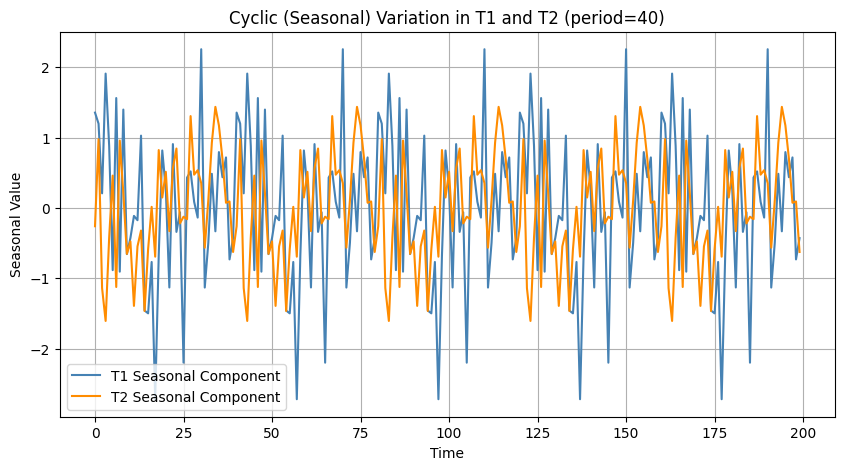

In [ ]:
# --- Plot the seasonal components ---
plt.figure(figsize=(10, 5))
plt.plot(result_T1.seasonal, label='T1 Seasonal Component', color='steelblue')
plt.plot(result_T2.seasonal, label='T2 Seasonal Component', color='darkorange')
plt.title('Cyclic (Seasonal) Variation in T1 and T2 (period=40)')
plt.xlabel('Time')
plt.ylabel('Seasonal Value')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# (C) Cross-correlation
cross_corr = ccf(df['T1'].dropna(), df['T2'].dropna())
lags = np.arange(len(cross_corr))
max_corr = cross_corr[np.argmax(np.abs(cross_corr))]
best_lag = lags[np.argmax(np.abs(cross_corr))]
print("Max_Correlation:", max_corr)
print("Lag_At_Max_Correlation:", best_lag)

Max_Correlation: 0.6115998863775256
Lag_At_Max_Correlation: 197


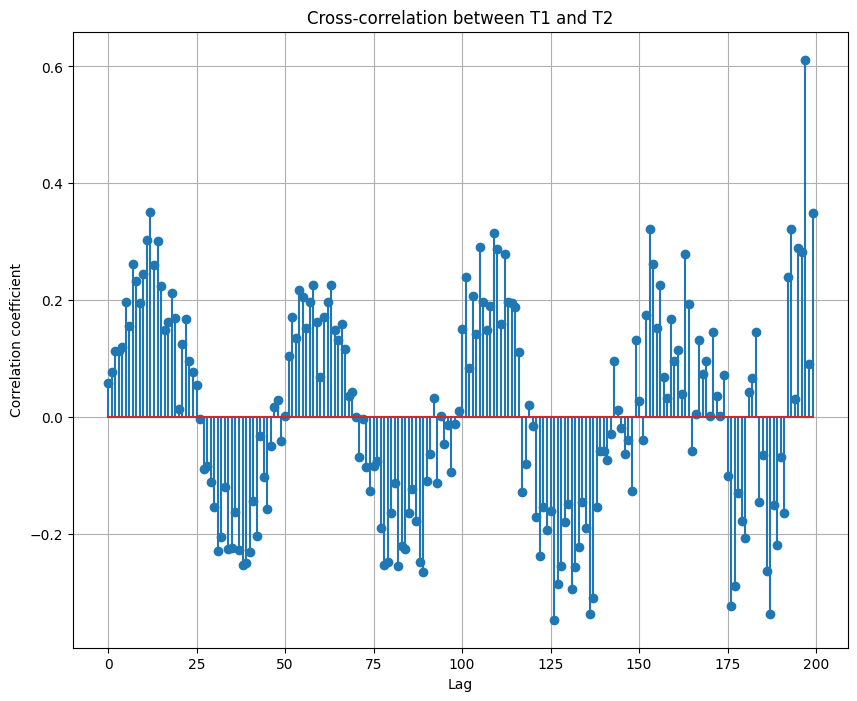

In [ ]:
# Plot cross-correlation
plt.stem(lags, cross_corr)
plt.title('Cross-correlation between T1 and T2')
plt.xlabel('Lag')
plt.ylabel('Correlation coefficient')
plt.grid(True)
plt.show()

**(A) Trend:**
The Augmented Dickey–Fuller (ADF) test returned p-values of **0.0013 for T1** and **0.0003 for T2**, both well below 0.05. This means the null hypothesis of non-stationarity can be rejected, confirming that **both T1 and T2 are stationary**. No persistent upward or downward trend is present; their means and variances remain stable over time.

**(B) Cyclic Variation:**
The seasonal decomposition shows low standard deviations of the seasonal components (**T1 ≈ 1.07**, **T2 ≈ 0.77**). These small amplitudes indicate only **weak, short-term cyclic oscillations** rather than strong periodic behavior. Both series fluctuate slightly around their means but lack consistent, repeating cycles. \
As seen in the plot, the seasonal components of T1 and T2 oscillate irregularly around zero, with no clear or dominant periodic pattern. The peaks and troughs appear asymmetric and inconsistent in spacing, suggesting that any cyclic movement is sporadic rather than systematic. Overall, the visual and statistical evidence together confirm that both time series exhibit only minor, irregular cyclic variation.

**(C) Cross Correlation:**
The cross-correlation function reveals a **maximum correlation of ≈ 0.61 at lag 197**, meaning that values of T1 and T2 align moderately when one series is shifted by roughly 197 time units. However, aside from that lag, most correlations remain close to zero, showing **no consistent synchronization** between the two time series. Overall, T1 and T2 share only limited temporal dependence and behave largely as independent processes.


**Cross-Correlation Plot Interpretation**

**What it means:**

* Each dot represents the correlation between **T1(t)** and **T2(t + lag)**.
* **Positive correlation** → both move in the same direction at that lag.
* **Negative correlation** → when one goes up, the other goes down.
* **Lag = 0** means simultaneous movement (no delay).
* **Lag > 0** means *T2 lags behind T1*; **Lag < 0** (if shown) would mean *T1 lags behind T2*.

**What the plot shows:**

* Most correlations hover close to **0**, which confirms **weak or no consistent relationship**.
* There are some **periodic peaks** of about **0.2–0.3**, showing mild repeating patterns.
* The **highest peak (~0.61 at lag ≈ 197)** is visible on the far right — meaning that if one series is shifted by almost the full length of the dataset, they align moderately.
* This suggests **no meaningful predictive relationship**, since the lag is too large to be physically or temporally relevant.
* The **alternating positive and negative bands** indicate some **cyclic-like noise or short-range structure**, but not true seasonality.


### Task 3.4:
Revisit your first hypotheses from Task 3.1 and interpret all findings from Task 3.2 and Task 3.3 in the light of your first ideas. How has your first impression changed? What have you been able to show through your analysis? What do the results mean in terms of predictive power?

**How the later analyses support or refine these ideas**

* **Stationarity (confirmed).** \
  *Evidence:* ADF p-values were **0.0013 (T1)** and **0.0003 (T2)** → both reject the unit-root null. The smoothed (n=10) views from Task 3.2 also showed stable levels. \
  Our first impression holds; both series are stationary around a constant mean.

* **Different volatility (confirmed).** \
  *Evidence:* The smoothed overlays showed **T1** retaining more pronounced short-term wiggles than **T2**; decomposition also indicated slightly larger seasonal/short-cycle amplitude for **T1** (**T1 seasonal std ≈ 1.07** vs **T2 ≈ 0.77**). \
  The volatility gap we saw visually is quantitatively supported.

* **No strong cycles (confirmed, with nuance).** \
  *Evidence:* Seasonal decomposition revealed **weak, irregular oscillations** only (small seasonal std for both series). No dominant, persistent period emerged. \
  The “low-amplitude, short-lived” cycle hypothesis stands; any cyclicity is mild and not reliably periodic.

* **Different processes / low coupling (confirmed).** \
  *Evidence:* Cross-correlation shows a **single moderate peak (0.61) at a very large lag (197)**, while correlations at practical/short lags are near zero. This suggests **no meaningful lead–lag relationship**.

---

**What we’ve shown**

* Both time series are **stationary**, have **weak/irregular cyclic components**, and **differ in volatility** (T1 > T2).
* **Cross-series linkage is weak** at meaningful lags; the large-lag correlation is not practically useful.



**Predictive Power**

The results indicate that both **T1** and **T2** have **limited predictive power** beyond the very short term.
Because both series are **stationary** and show **no strong trends or recurring seasonal patterns**, there are no long-term structures that can be exploited for extended forecasts. Their fluctuations are largely random around stable mean values.

The **weak cross-correlation** between T1 and T2 means that knowing one does not significantly help in predicting the other — they behave mostly **independently**. Therefore, **cross-predictive models** (where one variable is used to forecast the other) would not be effective.